## Let’s code

In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date, datetime, time, timezone

In [3]:
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
       data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data

In [4]:
ticker = 'DIS'
start = datetime (2020, 1,1)
end = datetime.today()

In [5]:
d = get_stock_data(ticker,start,end)
d.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2020-01-02,143.689270,148.199997,148.199997,145.100006,145.289993,9502100,DIS
1,2020-01-03,142.041016,146.500000,147.899994,146.050003,146.399994,7320200,DIS
2,2020-01-06,141.216888,145.649994,146.029999,144.309998,145.539993,8262500,DIS
3,2020-01-07,141.265350,145.699997,146.869995,145.419998,145.990005,6906500,DIS
4,2020-01-08,140.974457,145.399994,146.130005,144.820007,145.490005,6984200,DIS


In [6]:
d = d.pivot(index="Date", columns="Ticker", values="Close")
d.head()

Ticker,DIS
Date,
2020-01-02,148.199997
2020-01-03,146.500000
2020-01-06,145.649994
2020-01-07,145.699997
2020-01-08,145.399994


In [7]:
SPY = get_stock_data("SPY",start,end)
IYW = get_stock_data("IYW",start,end)
VT = get_stock_data("VT",start,end)
DBA = get_stock_data("DBA",start,end)
TLT = get_stock_data("TLT",start,end)
PDBC = get_stock_data("PDBC",start,end)
IAU = get_stock_data("IAU",start,end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
SPY.info()

<class 'pandas.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       1668 non-null   datetime64[s]
 1   Adj Close  1668 non-null   float64      
 2   Close      1668 non-null   float64      
 3   High       1668 non-null   float64      
 4   Low        1668 non-null   float64      
 5   Open       1668 non-null   float64      
 6   Volume     1668 non-null   int64        
 7   Ticker     1668 non-null   str          
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 104.4 KB


In [9]:
# Execute pivoting per data frame
SPY=SPY.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IYW=IYW.reset_index().pivot(index="Date", columns="Ticker", values="Close")
VT=VT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
DBA=DBA.reset_index().pivot(index="Date", columns="Ticker", values="Close")
TLT=TLT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
PDBC=PDBC.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IAU=IAU.reset_index().pivot(index="Date", columns="Ticker", values="Close")

In [10]:
stock=pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU],
                axis=1,
                join='outer')
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,324.869995,59.355000,81.809998,16.500000,137.009995,16.639999,29.219999
2020-01-03,322.410004,58.762501,81.070000,16.309999,139.119995,16.780001,29.620001
2020-01-06,323.640015,59.125000,81.370003,16.350000,138.330002,16.799999,29.920000
2020-01-07,322.730011,59.147499,81.120003,16.389999,137.649994,16.770000,30.040001
2020-01-08,324.450012,59.737499,81.449997,16.309999,136.740005,16.540001,29.820000


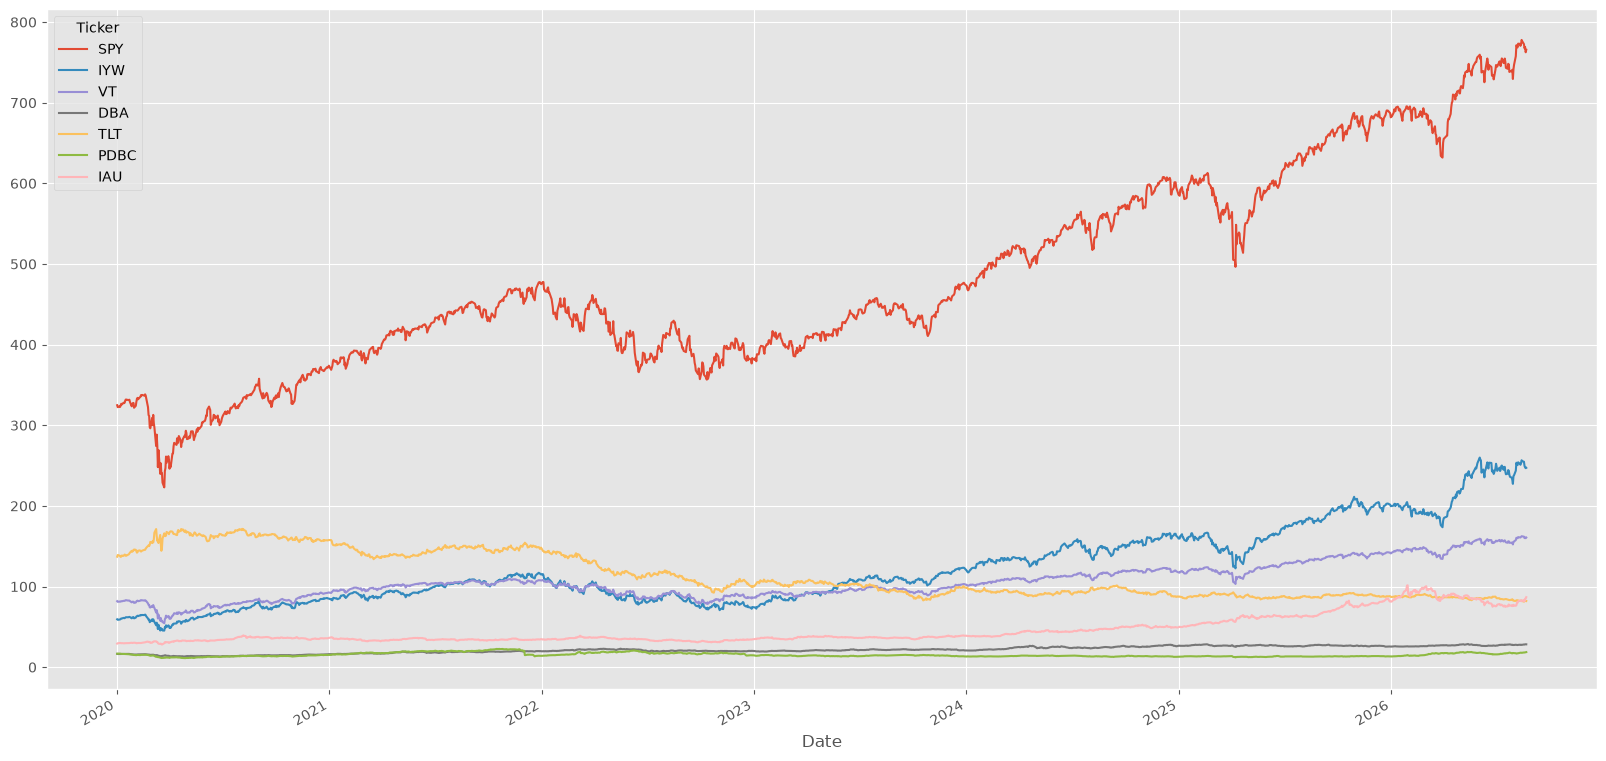

In [11]:
plt.style.use('ggplot')
stock.plot(figsize = (20, 10))
plt.show()

In [12]:
macro_shock=stock['2026-03-01':'2026-04-01']

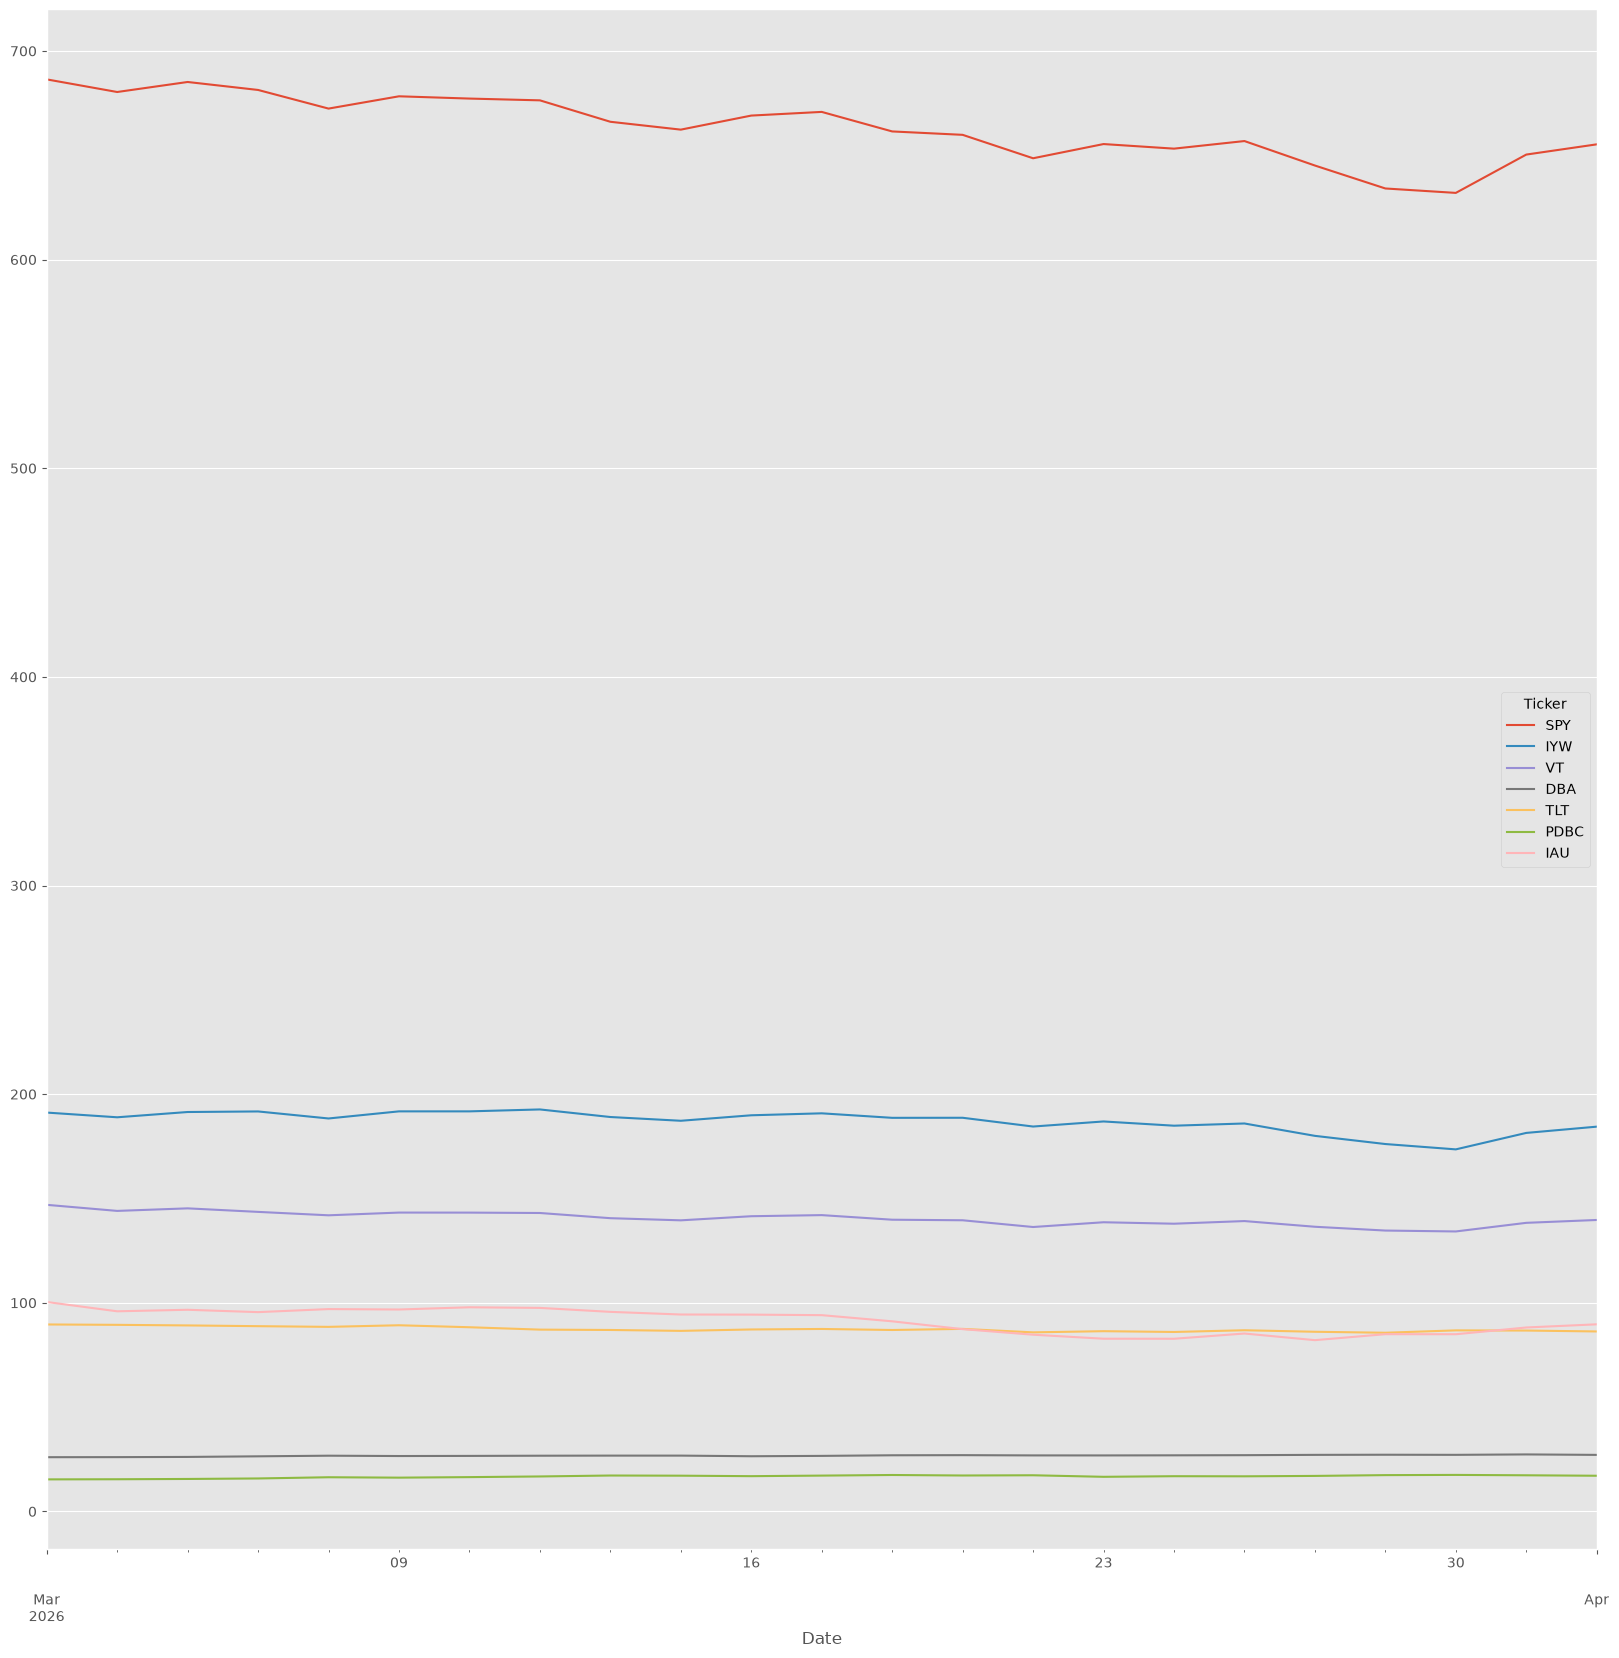

In [13]:
plt.style.use('ggplot')
macro_shock.plot(figsize = (20, 20))
plt.show()

In [14]:
x = macro_shock.index
s_y = macro_shock[['SPY']]
i_y = macro_shock[['IAU']]
d_y = macro_shock[['DBA']]
t_y = macro_shock[['TLT']]

Text(0.5, 0.98, 'Macro Shock')

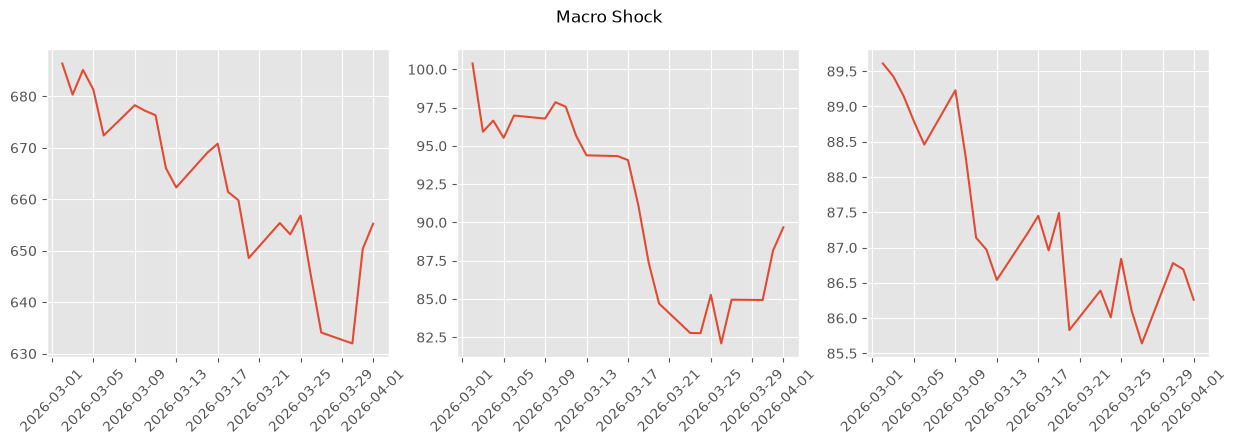

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(x, s_y)
axs[1].plot(x, i_y)
axs[2].plot(x, t_y)

for ax in axs:
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Macro Shock')

In [16]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date, datetime, time, timezone

In [17]:
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
       data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data

In [18]:
ticker = 'PDBC'
start = datetime(2025,1,1)
end = datetime.today()

In [19]:
df = get_stock_data(ticker, start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2025-01-02,12.639312,13.13,13.200,13.100,13.10,7044000,PDBC
1,2025-01-03,12.562302,13.05,13.100,13.040,13.10,2969000,PDBC
2,2025-01-06,12.591181,13.08,13.200,13.065,13.16,5883300,PDBC
3,2025-01-07,12.648938,13.14,13.180,13.133,13.15,3053200,PDBC
4,2025-01-08,12.629685,13.12,13.175,13.070,13.14,4955200,PDBC


In [20]:
df = df.drop(['Ticker', 'High', 'Low', 'Open', "Close", "Adj Close"], axis=1)

In [21]:
df.head()

Price,Date,Volume
0,2025-01-02,7044000
1,2025-01-03,2969000
2,2025-01-06,5883300
3,2025-01-07,3053200
4,2025-01-08,4955200


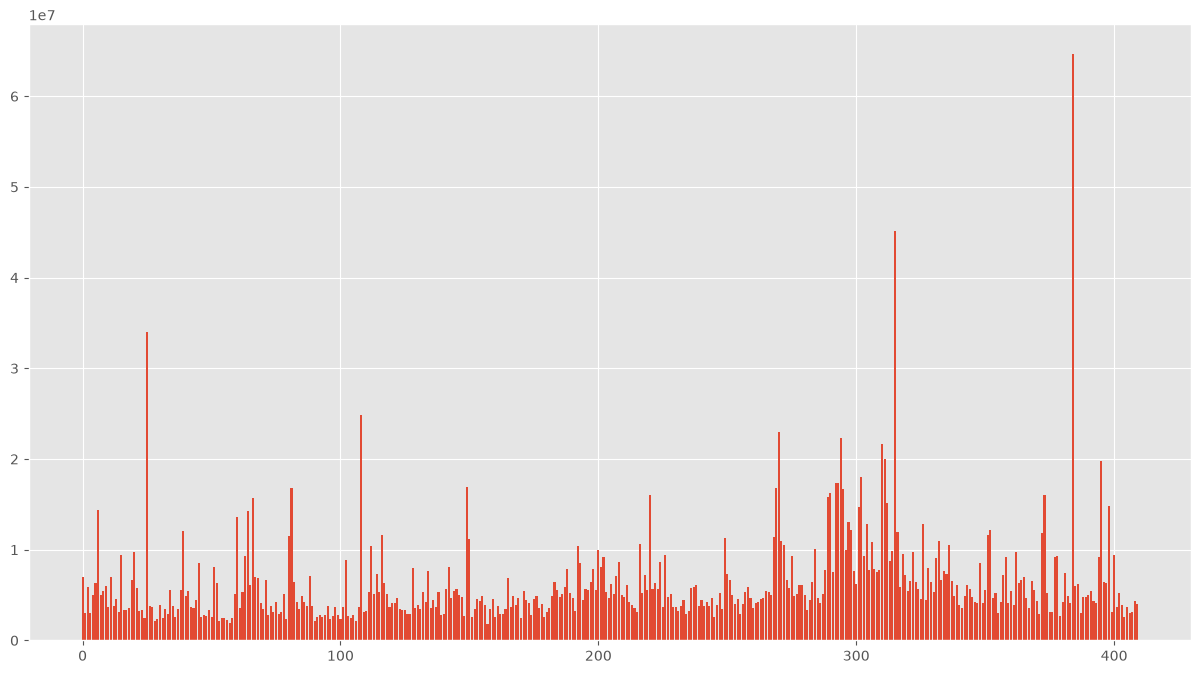

In [22]:
x = df.index
y = df['Volume']
plt.figure(figsize = (15,8))
plt.bar(x, y)
plt.show()

In [23]:
ticker = 'PDBC'
start = datetime(2025,1,1)
end = datetime.today()

In [24]:
df = get_stock_data(ticker, start, end)

[*********************100%***********************]  1 of 1 completed


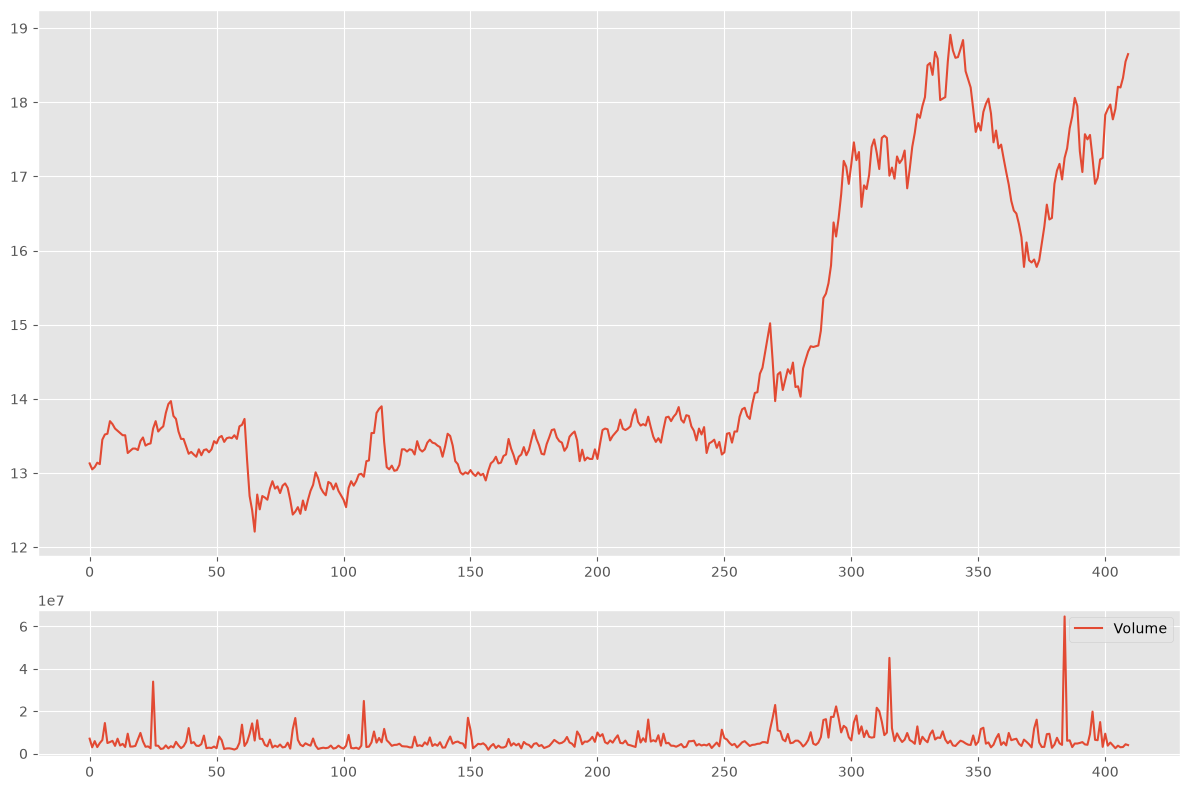

In [25]:

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
top_grid = plt.subplot2grid((4,4), (0,0), rowspan=3, colspan=4)
bottom_grid = plt.subplot2grid((4,4), (3,0), rowspan=2, colspan=4)

top_grid.plot(df.index, df['Close'], label='Close')
bottom_grid.plot(df.index, df['Volume'], label='Volume')

plt.tight_layout()

plt.legend()
plt.show()

In [26]:
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,324.869995,59.355000,81.809998,16.500000,137.009995,16.639999,29.219999
2020-01-03,322.410004,58.762501,81.070000,16.309999,139.119995,16.780001,29.620001
2020-01-06,323.640015,59.125000,81.370003,16.350000,138.330002,16.799999,29.920000
2020-01-07,322.730011,59.147499,81.120003,16.389999,137.649994,16.770000,30.040001
2020-01-08,324.450012,59.737499,81.449997,16.309999,136.740005,16.540001,29.820000


In [27]:
stock['SPY']

Date
2020-01-02    324.869995
2020-01-03    322.410004
2020-01-06    323.640015
2020-01-07    322.730011
2020-01-08    324.450012
                 ...    
2026-08-17    772.669983
2026-08-18    767.450012
2026-08-19    769.059998
2026-08-20    762.599976
2026-08-21    765.719971
Name: SPY, Length: 1668, dtype: float64

In [28]:
stock['SPY'].shift(1)

Date
2020-01-02           NaN
2020-01-03    324.869995
2020-01-06    322.410004
2020-01-07    323.640015
2020-01-08    322.730011
                 ...    
2026-08-17    776.340027
2026-08-18    772.669983
2026-08-19    767.450012
2026-08-20    769.059998
2026-08-21    762.599976
Name: SPY, Length: 1668, dtype: float64

In [29]:
spy_daily_pc=(stock['SPY']/stock['SPY'].shift(1)-1)*100

In [30]:
spy_daily_pc

Date
2020-01-02         NaN
2020-01-03   -0.757223
2020-01-06    0.381505
2020-01-07   -0.281178
2020-01-08    0.532954
                ...   
2026-08-17   -0.472737
2026-08-18   -0.675576
2026-08-19    0.209784
2026-08-20   -0.839989
2026-08-21    0.409126
Name: SPY, Length: 1668, dtype: float64

<Axes: xlabel='Date'>

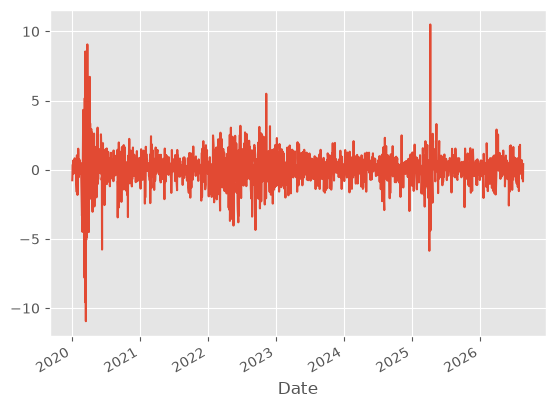

In [31]:
spy_daily_pc.plot()

In [32]:
spy_dayily_pc=(stock['SPY']/stock['SPY'].shift(1)-1)*100

In [33]:
spy_dayily_pc.iloc[0] =0

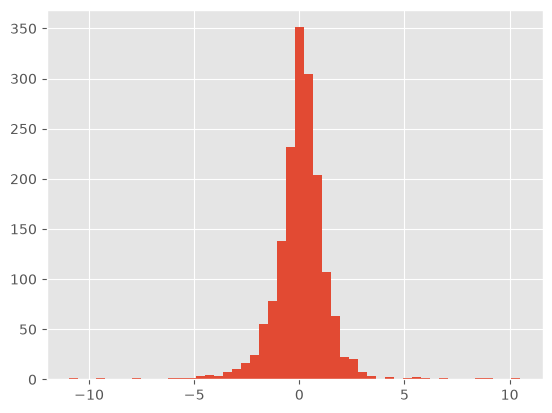

In [34]:
plt.hist(spy_dayily_pc, bins = 50)
plt.show()

In [35]:
stock

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,324.869995,59.355000,81.809998,16.500000,137.009995,16.639999,29.219999
2020-01-03,322.410004,58.762501,81.070000,16.309999,139.119995,16.780001,29.620001
2020-01-06,323.640015,59.125000,81.370003,16.350000,138.330002,16.799999,29.920000
2020-01-07,322.730011,59.147499,81.120003,16.389999,137.649994,16.770000,30.040001
2020-01-08,324.450012,59.737499,81.449997,16.309999,136.740005,16.540001,29.820000
...,...,...,...,...,...,...,...
2026-08-17,772.669983,254.789993,161.830002,28.139999,81.349998,18.209999,83.110001
2026-08-18,767.450012,249.580002,160.059998,28.030001,81.660004,18.200001,81.709999
2026-08-19,769.059998,247.800003,160.699997,28.290001,83.019997,18.330000,84.839996


In [36]:
stock_dayily_pc=(stock-stock.shift(1))/stock.shift(1) * 100
stock_dayily_pc.head(10)

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.757223,-0.998229,-0.904532,-1.151518,1.540034,0.841354,1.368931
2020-01-06,0.381505,0.616889,0.370054,0.245254,-0.567850,0.119181,1.012827
2020-01-07,-0.281178,0.038053,-0.307239,0.244642,-0.491584,-0.178564,0.401072
2020-01-08,0.532954,0.997507,0.406798,-0.488102,-0.661089,-1.371494,-0.732361
2020-01-09,0.678065,1.138314,0.491101,0.245254,0.351028,-0.544136,-0.603623
2020-01-10,-0.287771,-0.165512,-0.207695,0.917429,0.889084,0.000000,0.674766
2020-01-13,0.687735,1.355323,0.710090,-0.606063,-0.303379,-0.607905,-0.804289
2020-01-14,-0.152462,-0.588855,-0.036468,0.548781,0.514412,0.305806,-0.135138


In [37]:
stock_d_cr=stock_dayily_pc.cumsum()
stock_d_cr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.757223,-0.998229,-0.904532,-1.151518,1.540034,0.841354,1.368931
2020-01-06,-0.375718,-0.381340,-0.534478,-0.906264,0.972184,0.960535,2.381757
2020-01-07,-0.656896,-0.343287,-0.841717,-0.661622,0.480600,0.781971,2.782830
2020-01-08,-0.123942,0.654220,-0.434919,-1.149724,-0.180489,-0.589523,2.050469
...,...,...,...,...,...,...,...
2026-08-17,100.228208,172.404177,80.750544,60.215079,-43.103039,27.895426,115.659580
2026-08-18,99.552633,170.359359,79.656801,59.824181,-42.721963,27.840520,113.975064
2026-08-19,99.762416,169.646162,80.056650,60.751759,-41.056530,28.554801,117.805681


<Axes: xlabel='Date'>

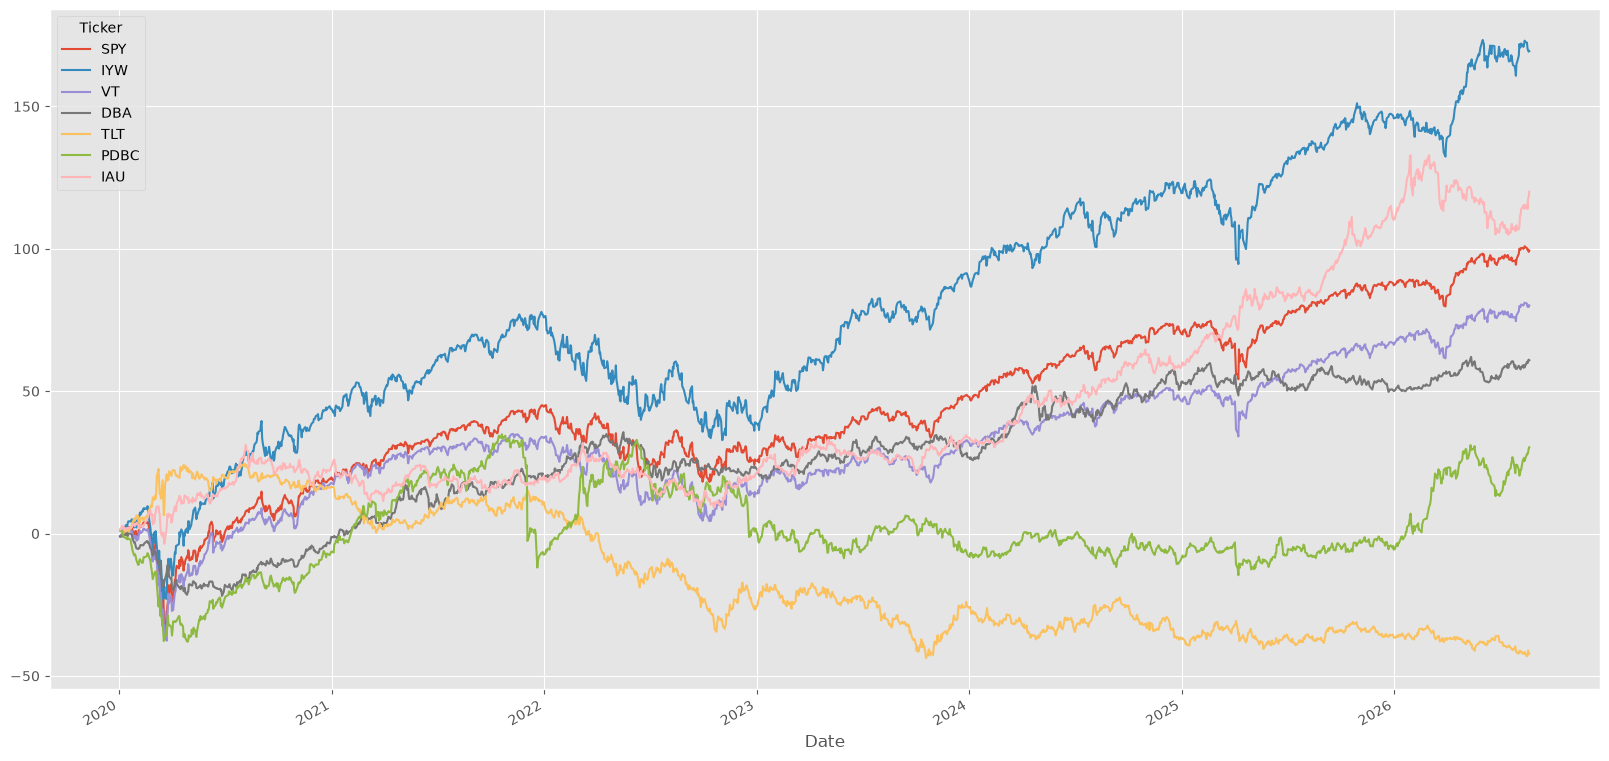

In [38]:
stock_d_cr.plot(figsize = (20, 10))

In [39]:
df_corr = stock_dayily_pc.corr()
df_corr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Ticker,,,,,,,
SPY,1.000000,0.915049,0.972277,0.214958,-0.106273,0.247506,0.148841
IYW,0.915049,1.000000,0.881500,0.180445,-0.060166,0.191347,0.158696
VT,0.972277,0.881500,1.000000,0.239061,-0.089042,0.271606,0.215384
DBA,0.214958,0.180445,0.239061,1.000000,-0.091838,0.401691,0.139553
TLT,-0.106273,-0.060166,-0.089042,-0.091838,1.000000,-0.137820,0.202246
PDBC,0.247506,0.191347,0.271606,0.401691,-0.137820,1.000000,0.235799
IAU,0.148841,0.158696,0.215384,0.139553,0.202246,0.235799,1.000000


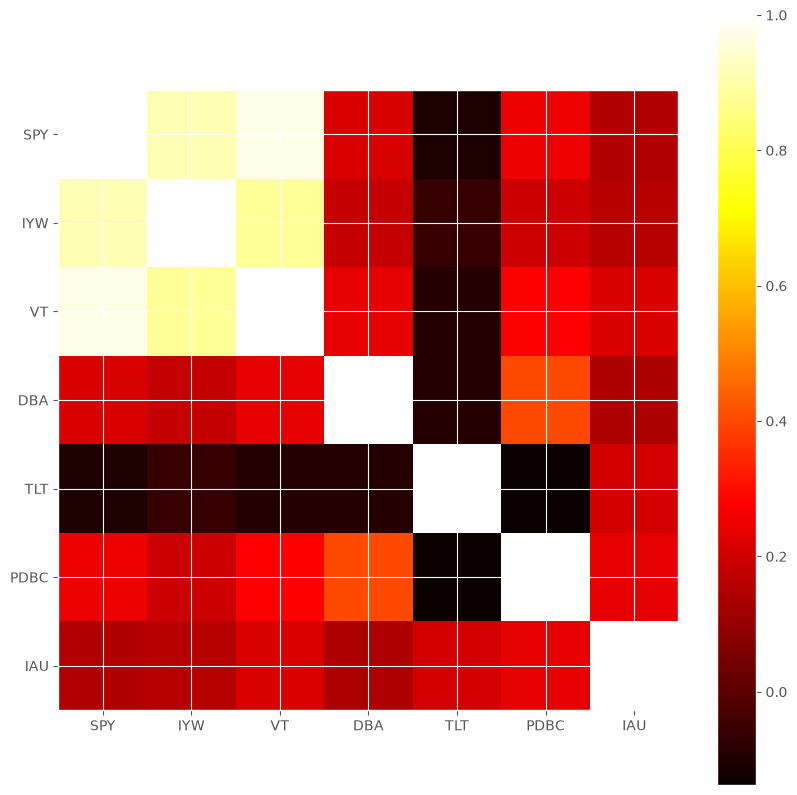

In [40]:
plt.imshow (df_corr, cmap ='hot', interpolation ='none')
plt.colorbar()
plt.xticks(range(len(df_corr)),df_corr.columns)
plt.yticks(range(len(df_corr)),df_corr.columns)

plt.gcf().set_size_inches(10,10)

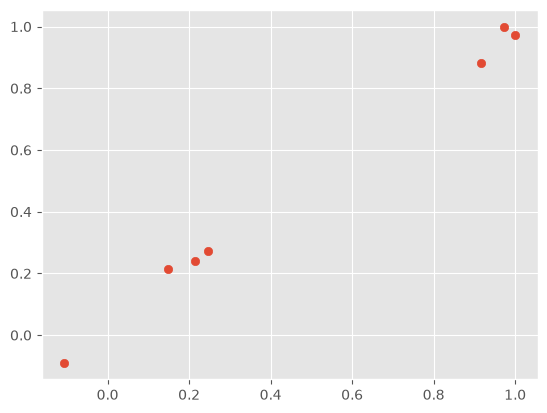

In [41]:
plt.scatter(df_corr.SPY,df_corr.VT)
plt.show()

In [42]:
periods = 75

vol = stock_dayily_pc.rolling(window=periods).std()

vol

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-08-17,0.840447,1.865330,0.954935,0.864948,0.588101,1.415991,1.534011
2026-08-18,0.838902,1.881557,0.950713,0.865516,0.590368,1.415853,1.534975
2026-08-19,0.838737,1.879730,0.951389,0.871496,0.623130,1.414783,1.599618


<Axes: xlabel='Date'>

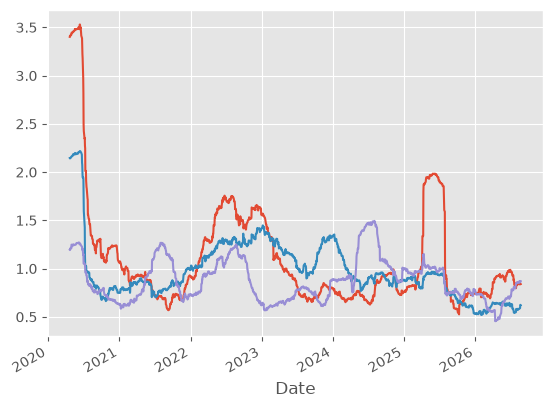

In [43]:
vol["SPY"].plot()
vol["TLT"].plot()
vol["DBA"].plot()